# Fashion-MNIST Baseline Classifier

Goal: understand how 28 by 28 grayscale images become numbers a classifier can learn from.

Prediction before loading data:
I expect one image to have 28 * 28 = 784 pixel values.
I expect a batch to include many images at once

In [1]:
from IPython.core.pylabtools import figsize

BATCH_SIZE = 32

In [3]:
from pathlib import Path


def find_project_root(start: Path) -> Path:
   for candidate in [start, *start.parents]:
       if (candidate / "pyproject.toml").exists():
           return candidate
   raise FileNotFoundError("Could not find project root containing pyproject.toml.")


project_root = find_project_root(Path.cwd()).resolve()
data_dir = project_root / "data" / "fashion-mnist"

print(project_root)
print(data_dir)

C:\Users\giloz\dev\intuitive_understanding_machine_learning
C:\Users\giloz\dev\intuitive_understanding_machine_learning\data\fashion-mnist


In [4]:
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor

train_dataset = FashionMNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset = FashionMNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=ToTensor(),
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

images, labels = next(iter(train_loader))
print(f"Images batch shape: {images.shape}")
print(f"Labels batch shape: {labels.shape}")
print(f"First label number: {labels[0].item()}")

100%|██████████| 26.4M/26.4M [00:00<00:00, 35.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 1.24MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 17.1MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Images batch shape: torch.Size([32, 1, 28, 28])
Labels batch shape: torch.Size([32])
First label number: 6


In [6]:
class_names = train_dataset.classes

first_image = images[0]
first_label = labels[0]

print(f"First image shape: {first_image.shape}")
print(f"Pixel min: {first_image.min().item():.3f}")
print(f"Pixel max: {first_image.max().item():.3f}")
print(f"Label number: {first_label.item()}")
print(f"Label name: {class_names[first_label.item()]}")

First image shape: torch.Size([1, 28, 28])
Pixel min: 0.000
Pixel max: 1.000
Label number: 6
Label name: Shirt


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

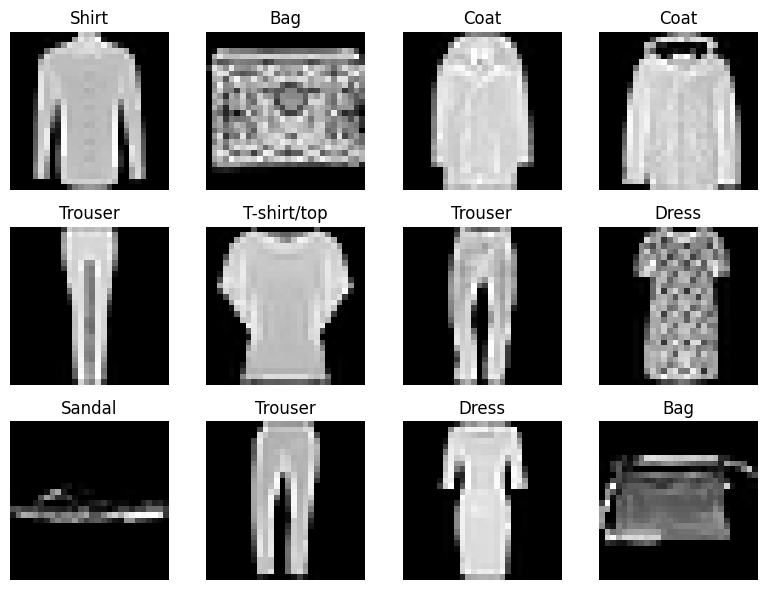

Saved sample image grid to: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-06-image-classification-baseline\sample_images.png


In [7]:
import matplotlib.pyplot as plt

artifacts_dir = project_root / "artifacts" / "week-06-image-classification-baseline"
artifacts_dir.mkdir(parents=True, exist_ok=True)

sample_images_path = artifacts_dir / "sample_images.png"

fig, axes = plt.subplots(3, 4, figsize=(8,6))

for axis, image, label in zip(axes.ravel(), images[:12], labels[:12]):
    axis.imshow(image.squeeze(), cmap="gray")
    axis.set_title(class_names[label.item()])
    axis.axis("off")

fig.tight_layout()
fig.savefig(sample_images_path, dpi=150)
plt.show()

print(f"Saved sample image grid to: {sample_images_path}")